<a href="https://colab.research.google.com/github/apy9955/Data_Cleaning_And_Reporting_Automation/blob/main/Data_Cleaning_And_Reporting_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# File Upload
from google.colab import files

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
uploaded = files.upload()

Saving stores_sales_forecasting.csv to stores_sales_forecasting.csv


In [3]:
df = pd.read_csv("stores_sales_forecasting.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2121, 21)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (2121, 21)


In [9]:
print("Total Sales:", df["Sales"].sum())
print("Average Sales:", df["Sales"].mean())
print("Maximum Sale:", df["Sales"].max())

Total Sales: 741999.7953
Average Sales: 349.8348869872702
Maximum Sale: 4416.174


In [10]:
print("Total Profit:", df["Profit"].sum())
print("Average Profit:", df["Profit"].mean())

Total Profit: 18451.272800000006
Average Profit: 8.699327109853845


In [11]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture    741999.7953
Name: Sales, dtype: float64


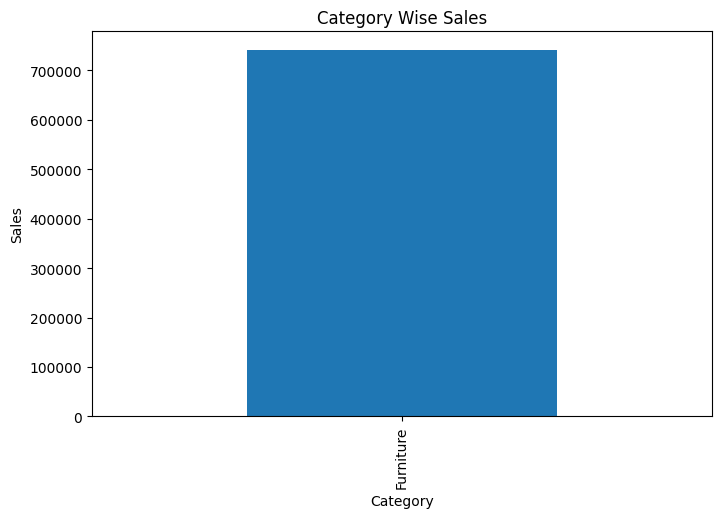

In [12]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [13]:
region_profit = df.groupby("Region")["Profit"].sum()
print(region_profit)

Region
Central    -2871.0494
East        3046.1658
South       6771.2061
West       11504.9503
Name: Profit, dtype: float64


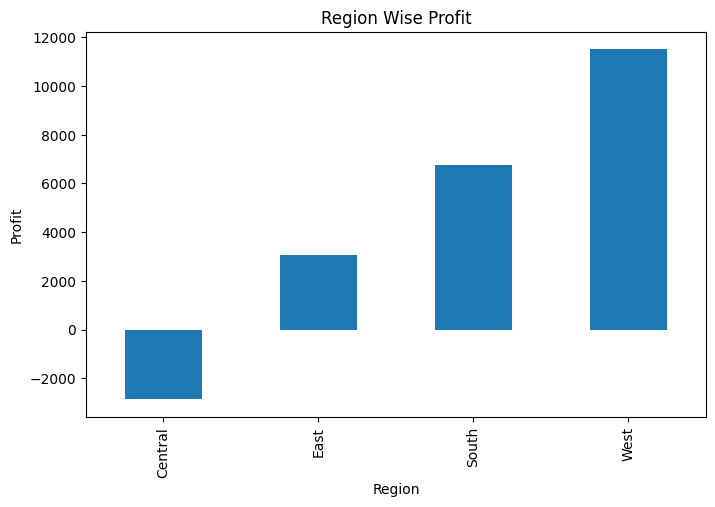

In [14]:
region_profit.plot(kind="bar", figsize=(8,5))

plt.title("Region Wise Profit")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

In [15]:
report = pd.DataFrame({
    "Metric":[
        "Total Records",
        "Total Sales",
        "Average Sales",
        "Maximum Sale",
        "Total Profit",
        "Average Profit"
    ],
    "Value":[
        len(df),
        df["Sales"].sum(),
        df["Sales"].mean(),
        df["Sales"].max(),
        df["Profit"].sum(),
        df["Profit"].mean()
    ]
})

report

,Metric,Value
0,Total Records,2121.000000
1,Total Sales,741999.795300
2,Average Sales,349.834887
3,Maximum Sale,4416.174000
4,Total Profit,18451.272800
5,Average Profit,8.699327


In [17]:
report.to_csv("Final_Report.csv", index=False)

In [18]:
import os

os.listdir()

['.config', 'stores_sales_forecasting.csv', 'Final_Report.csv', 'sample_data']

In [19]:
report.to_csv("Final_Report.csv", index=False)

import os
print(os.listdir())

['.config', 'stores_sales_forecasting.csv', 'Final_Report.csv', 'sample_data']


In [20]:
from google.colab import files

files.download('Final_Report.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>